In [16]:
import pandas as pd

In [17]:
df = pd.read_csv("customer_churn_dataset/Churn_Modelling.csv")

In [18]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [20]:
df.duplicated().sum()

0

In [21]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [22]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [23]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [24]:
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

In [25]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [26]:
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)
df = df.astype({col: int for col in df.columns if df[col].dtype == 'bool'})

In [27]:
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,1,0,0,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,1,0,1


In [28]:
X = df.drop(columns=['Exited'])
y = df['Exited']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((8000, 11), (2000, 11), (8000,), (2000,))

In [30]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [31]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
X_train_scaled

array([[ 0.35649971, -0.6557859 ,  0.34567966, ..., -0.57946723,
        -0.57638802,  0.91324755],
       [-0.20389777,  0.29493847, -0.3483691 , ...,  1.72572313,
        -0.57638802,  0.91324755],
       [-0.96147213, -1.41636539, -0.69539349, ..., -0.57946723,
         1.73494238,  0.91324755],
       ...,
       [ 0.86500853, -0.08535128, -1.38944225, ..., -0.57946723,
        -0.57638802, -1.09499335],
       [ 0.15932282,  0.3900109 ,  1.03972843, ..., -0.57946723,
        -0.57638802,  0.91324755],
       [ 0.47065475,  1.15059039, -1.38944225, ...,  1.72572313,
        -0.57638802,  0.91324755]])

In [33]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [83]:
model = Sequential()
model.add(Dense(11, activation='relu', input_dim=11))
model.add(Dense(11, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

c:\Users\IRVINEi\miniconda3\envs\polynominal_regression\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [84]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [85]:
model.compile(loss='binary_crossentropy', optimizer='adam',metrics=['accuracy'])

In [86]:
history = model.fit(X_train_scaled,y_train,epochs = 100,validation_split=0.2)

Epoch 1/100


200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6436 - loss: 0.6231 - val_accuracy: 0.8000 - val_loss: 0.4812
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7896 - loss: 0.4820 - val_accuracy: 0.8006 - val_loss: 0.4534
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7894 - loss: 0.4648 - val_accuracy: 0.8119 - val_loss: 0.4341
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8052 - loss: 0.4355 - val_accuracy: 0.8200 - val_loss: 0.4163
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8235 - loss: 0.4103 - val_accuracy: 0.8288 - val_loss: 0.4017
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8324 - loss: 0.3958 - val_accuracy: 0.8369 - val_loss: 0.3905
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8277 - loss: 0.3966 - val_accuracy: 0.8400 - val_loss: 0.3818
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8471 - loss: 0.3799 - val_accuracy: 0.8431

In [87]:
model.layers[0].get_weights()

[array([[ 0.14016506,  0.0938253 ,  0.12422425,  0.46155173,  0.0187484 ,
         -0.04993908,  0.12896162,  0.17115042, -0.00211761,  0.16585346,
          0.07531663],
        [-0.55468243,  0.08427998, -0.47529447,  0.13318741, -0.29687876,
          0.21707726, -0.13488413, -0.16432096,  0.8791192 ,  1.005025  ,
          0.52268386],
        [-0.00155757,  0.32496682, -0.15918635, -0.1502426 ,  0.24607103,
         -0.02518287, -0.04615646,  0.29440388, -0.11319029,  0.205557  ,
          0.00541729],
        [-0.67279565, -0.2529529 , -0.06854567, -0.17699598, -0.44703323,
         -0.13633001,  0.68746215, -0.1910098 ,  0.01545144, -0.5799001 ,
          0.00905936],
        [-0.47382173,  1.0608618 , -0.50556225, -0.61366576, -0.26507244,
         -0.9135209 ,  0.17027484, -0.02168556,  0.9879602 , -0.17129906,
          0.6360802 ],
        [-0.09971082,  0.10045884, -0.06801818, -0.01142454, -0.00897552,
         -0.05144669, -0.37295997,  0.36380547,  0.09182094,  0.0615119

In [88]:
model.layers[0].get_weights()

[array([[ 0.14016506,  0.0938253 ,  0.12422425,  0.46155173,  0.0187484 ,
         -0.04993908,  0.12896162,  0.17115042, -0.00211761,  0.16585346,
          0.07531663],
        [-0.55468243,  0.08427998, -0.47529447,  0.13318741, -0.29687876,
          0.21707726, -0.13488413, -0.16432096,  0.8791192 ,  1.005025  ,
          0.52268386],
        [-0.00155757,  0.32496682, -0.15918635, -0.1502426 ,  0.24607103,
         -0.02518287, -0.04615646,  0.29440388, -0.11319029,  0.205557  ,
          0.00541729],
        [-0.67279565, -0.2529529 , -0.06854567, -0.17699598, -0.44703323,
         -0.13633001,  0.68746215, -0.1910098 ,  0.01545144, -0.5799001 ,
          0.00905936],
        [-0.47382173,  1.0608618 , -0.50556225, -0.61366576, -0.26507244,
         -0.9135209 ,  0.17027484, -0.02168556,  0.9879602 , -0.17129906,
          0.6360802 ],
        [-0.09971082,  0.10045884, -0.06801818, -0.01142454, -0.00897552,
         -0.05144669, -0.37295997,  0.36380547,  0.09182094,  0.0615119

In [89]:
y_log = model.predict(X_test_scaled)

35/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [90]:
y_pred = (y_log > 0.5).astype(int)

In [91]:
y_pred

array([[0],
       [0],
       [0],
       ...,
       [1],
       [0],
       [0]])

In [92]:
from sklearn.metrics import accuracy_score

In [93]:
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Accuracy Score: 0.86


In [94]:
import matplotlib.pyplot as plt

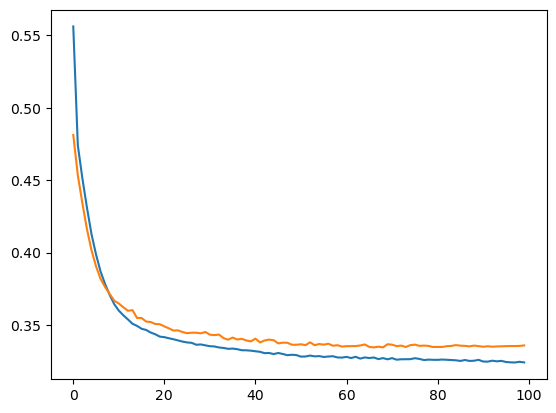

In [95]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])


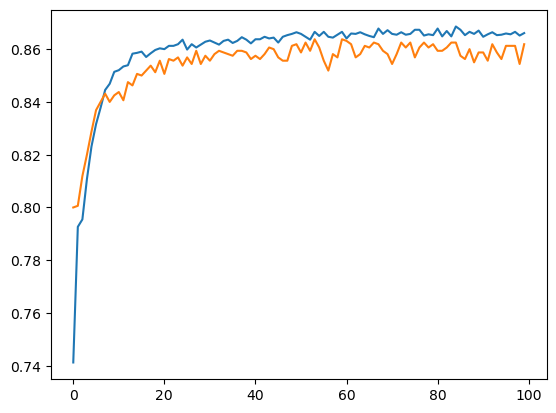

In [96]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
